In [13]:
import random
import sys
import typing
from typing import Sequence as Seq

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np
import pandas as pd
import torch
from torch import Tensor

sys.path.insert(0, "..")
from src.simulator.cache_simulator import encode_page_sets
from src.simulator.cache_simulator import PageClockSweepCache
from dqntrainer import DQN, DQNTrainer

In [14]:
print(
    'Before training the model, we need a name for it to avoid clashing with '
    'other models. I suggest something like "<benchmark>-<size>"'
)
NAME = input('Name: ')

Before training the model, we need a name for it to avoid clashing with other models. I suggest something like "<benchmark>-<size>"


In [15]:
print('We also need the capacity of the cache so was can simulate it.')
CACHE_CAPACITY_PAGES = int(input('Cache capacity in 8kb pages: '))

We also need the capacity of the cache so was can simulate it.


In [16]:
TARGET_COLS = 1000 # From the paper

In [17]:
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
print(f'Using device {device}')

rng = random.Random()

Using device cuda


In [18]:
dfs: list[pd.DataFrame] = []
for i in range(1, 23):
    df = pd.read_csv(f'../page_access/tpch/q{i}.csv')
    df['query'] = i
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

queries: list[list[tuple[str, int]]] = [
    list(zip(g['table'], g['block']))
    for _, g in df.groupby('query')
]
query_id_map = {idx: query for idx, query in enumerate(queries)}

raw_page_sets: list[set[tuple[str, int]]] = []
for query in queries:
    raw_page_sets.append(set(query))

page_sets, page_to_id = encode_page_sets(raw_page_sets)

table2n_blocks: dict[str, int] = {}
for group in queries:
    for table, block in group:
        table2n_blocks[table] = max(table2n_blocks.get(table, 0), block + 1)

tables = table2n_blocks.keys()

In [19]:
N_EPISODES = 1
dqn_trainer = DQNTrainer(
    table_to_n_blocks=table2n_blocks,
    queryid_to_tablepages=query_id_map,
    queryid_to_tablepageids=page_sets,
    tablepage_to_tablepageid=page_to_id,
    target_cols=TARGET_COLS,
    rng=rng,
)
dqn, log = dqn_trainer.train(
    update_steps=2,
    epsilon_schedule=np.geomspace(0.9, 0.01, num=N_EPISODES),
    gamma=0.9,
    tau=0.1,
    history_size=100,
    mini_batch_size=None,
    cache_capacity_pages=CACHE_CAPACITY_PAGES,
    device=device,
)

Episode 0/0: 100%|██████████| 1/1 [00:34<00:00, 34.92s/it, loss=1.0485e-03]    


In [20]:
torch.save(dqn.state_dict(), f'{NAME}.pt')

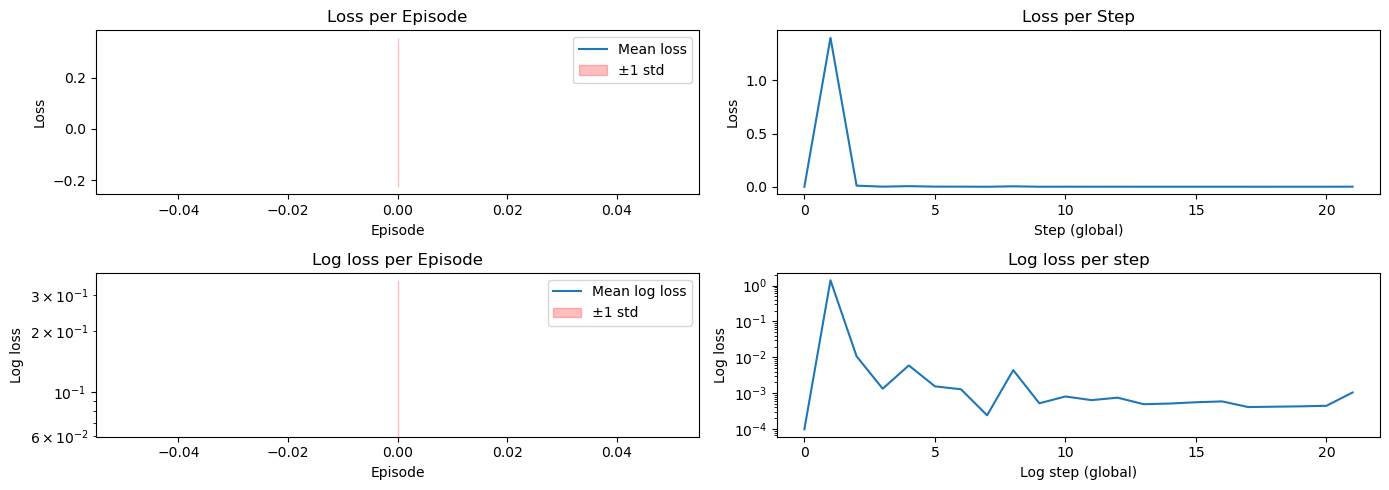

In [21]:
episodes = np.arange(len(log.episode_mean_loss))
mean = np.array(log.episode_mean_loss)
std = np.array(log.episode_std_loss)

fig, axes = plt.subplots(2, 2, figsize=(14, 5))
axes = typing.cast(Seq[Seq[Axes]], axes)

ax = axes[0][0]
ax.plot(episodes, mean, label="Mean loss")
ax.fill_between(episodes, mean - std, mean + std, alpha=0.25, label="±1 std", color='red')
ax.set(xlabel="Episode", ylabel="Loss", title="Loss per Episode")
ax.legend()

ax = axes[1][0]
ax.plot(episodes, mean, label="Mean log loss")
ax.fill_between(episodes, mean - std, mean + std, alpha=0.25, label="±1 std", color='red')
ax.set_yscale('log')
ax.set(xlabel="Episode", ylabel="Log loss", title="Log loss per Episode")
ax.legend()

ax = axes[0][1]
ax.plot(log.step_loss)
ax.set(xlabel="Step (global)", ylabel="Loss", title="Loss per Step")

ax = axes[1][1]
ax.plot(log.step_loss)
ax.set_yscale('log')
ax.set(xlabel="Log step (global)", ylabel="Log loss", title="Log loss per step")

fig.tight_layout()
plt.show()

In [22]:
input_dimension = 2 * len(tables) * TARGET_COLS
dqn = DQN(input_dimension)
dqn.load_state_dict(torch.load(f'{NAME}.pt'))
dqn.to(device)
dqn.eval()

/tmp/ipykernel_66464/1996120458.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dqn.load_state_dict(torch.load(f'{NAME}.pt'))


DQN(
  (net): Sequential(
    (0): Linear(in_features=44000, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [31]:
cache = PageClockSweepCache(CACHE_CAPACITY_PAGES)

remaining_queries = list(query_id_map.keys())
schedule = []

hit_rate_history = []
best_q_value_history = []

# Scheduling loop
while len(remaining_queries) > 0:
    # Get the query with the highest Q-value
    query_id_to_q_value = {
        query_id: dqn_trainer.q_value(dqn, cache, query_id, device).item()
        for query_id in remaining_queries
    }
    best_query_id = max(
        query_id_to_q_value,
        key=lambda qid: query_id_to_q_value[qid]
    )

    # Add the best query to the schedule, remove it from the queue
    schedule.append(best_query_id)
    remaining_queries.remove(best_query_id)
    best_q_value_history.append(query_id_to_q_value[best_query_id])

    # Update cache by simulating the selected query
    hit_rate, next_cache = dqn_trainer.execute(best_query_id, cache)
    hit_rate_history.append(hit_rate)
    cache = next_cache

In [ ]:
print('SCHEDULE')
print([f'q{query_id}' for query_id in schedule])
print(f"\n{'Query ID':<12} {'Q-Value':<12} {'Hit Rate':<12}")
print("-" * 36)
for query_id, q_value, hit_rate in zip(schedule, best_q_value_history, hit_rate_history):
    print(f'{query_id:<12} {q_value:<12.4f} {hit_rate:<12.4f}')
print("-" * 36)
print(f'Average hit rate: {sum(hit_rate_history)/len(hit_rate_history):.4f}')

SCHEDULE
['q19', 'q10', 'q1', 'q12', 'q4', 'q8', 'q14', 'q11', 'q2', 'q20', 'q0', 'q3', 'q6', 'q9', 'q17', 'q5', 'q15', 'q16', 'q18', 'q21', 'q13', 'q7']

Query ID     Q-Value      Hit Rate    
------------------------------------
19           0.1254       0.0000      
10           0.1153       0.0008      
1            0.1106       0.0086      
12           0.1085       0.0000      
4            0.1169       0.0000      
8            0.1036       0.0000      
14           0.1098       0.0000      
11           0.0985       0.0000      
2            0.0991       0.0000      
20           0.0888       0.0044      
0            0.0976       0.0000      
3            0.0884       0.0044      
6            0.0946       0.0001      
9            0.0849       0.0016      
17           0.0896       0.0037      
5            0.0875       0.0000      
15           0.0845       0.0000      
16           0.0687       0.0181      
18           0.0699       0.0011      
21           0.0235       0.